In [45]:
import jax
import jax.numpy as jnp
from jax import lax

%run ./scattering_length.ipynb
%run ./eta.ipynb
%run ./contact.ipynb

def irr_loss_eng(intensity, detuning, time_interval=1.0):
    I = jnp.asarray(intensity, dtype= jnp.float32)
    v = jnp.asarray(detuning, dtype= jnp.float32)
    N = I.shape[0]
    time_grid = jnp.linspace(0.0, time_interval, N)
    dt = time_grid[1]-time_grid[0]
    a_s = scat_len(I, v)
    eta = solve_eta(a_s, dt)
    mol_dens = mol_density(a_s, eta, dt) 

    return mol_dens 

def bounded_I(raw_I, I_max=100.0):
    return I_max * jax.nn.sigmoid(raw_I)
    
def bounded_v(raw_v, abs_v_max=100.0):
    return abs_v_max * jnp.tanh(raw_v)

def reg_loss_eng(raw_I, raw_v, I_max = 100.0, abs_v_max = 100.0, time_interval=1.0):
    I = bounded_I(raw_I, I_max)
    v = bounded_v(raw_v, abs_v_max)
    return irr_loss_eng(I, v, time_interval)




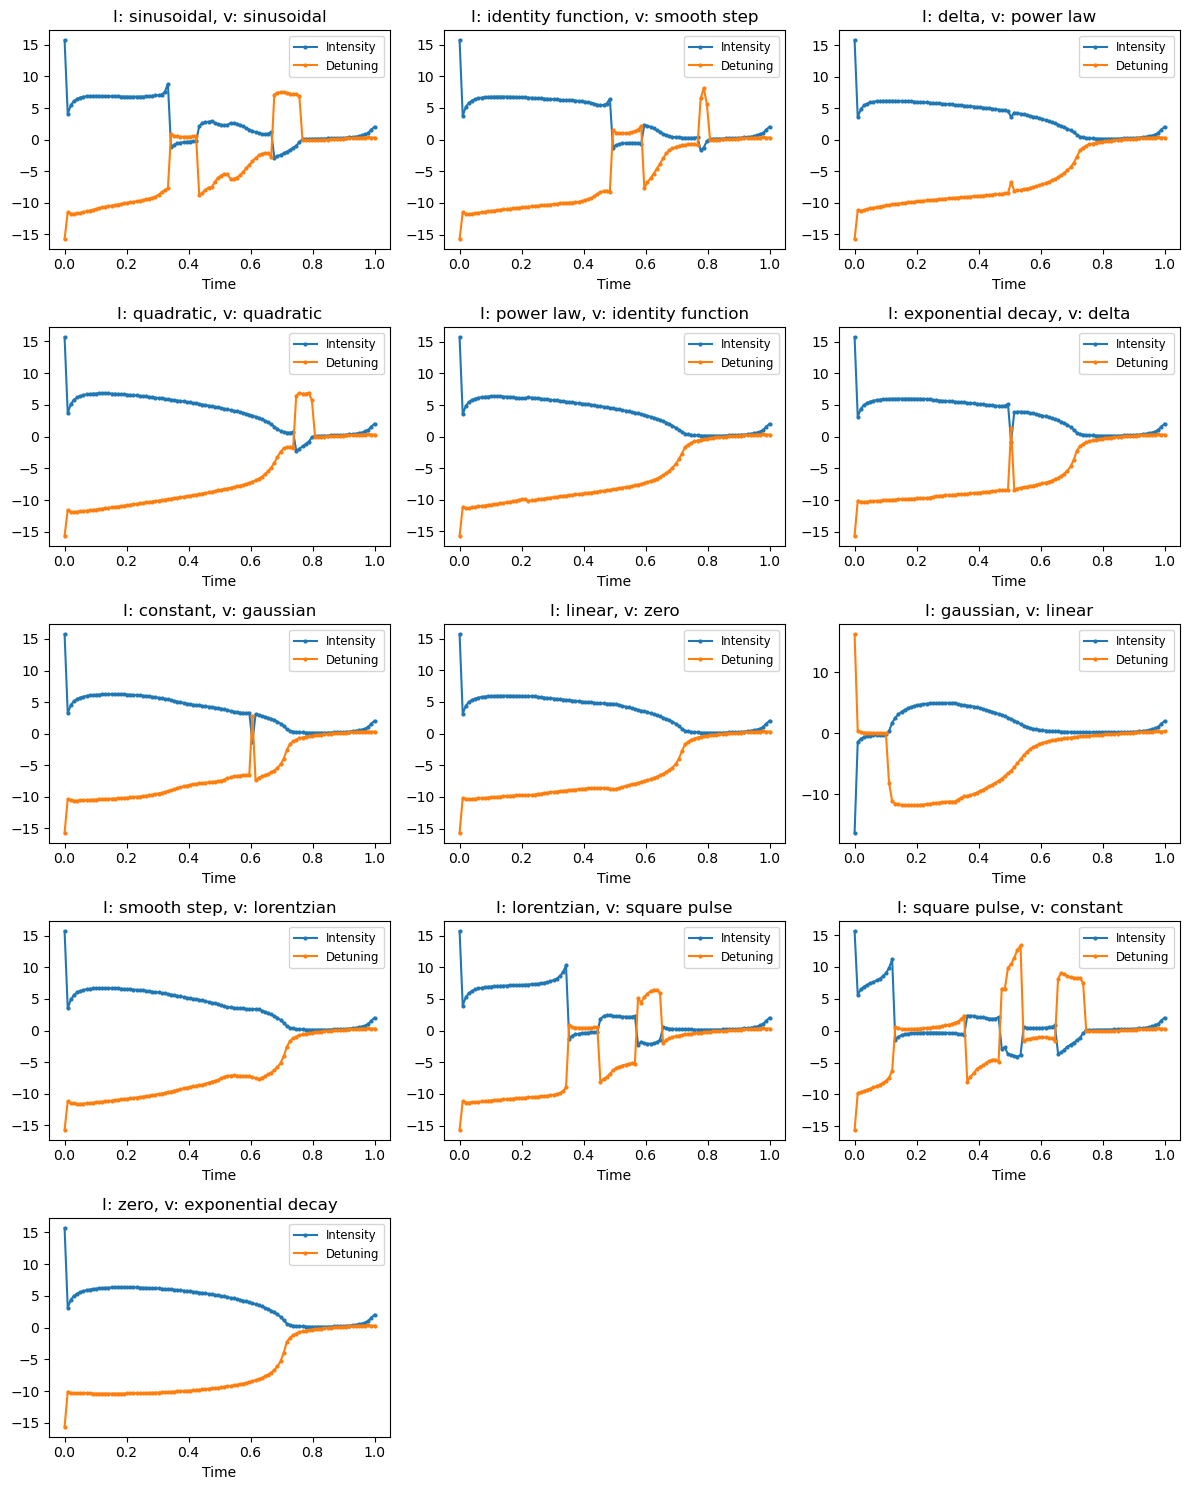

In [34]:
# Irr - Steps = 1,000
%run ./optimiser.ipynb

def loss_fn(params):
    return -irr_loss_eng(params["I"], params['v'])
    
def opt_irr_loss(params):
    return optimise(loss_fn, params, steps=1000)

%run ./test.ipynb
test_run = run_random_tests(
    opt_irr_loss,
    {
        "I": {'name': "Intensity"},
        "v": {'name': "Detuning", "positive": False},
    },
    array_length=100,
    plot_title="",
    plot_columns=3,
    make_plots=True,
)


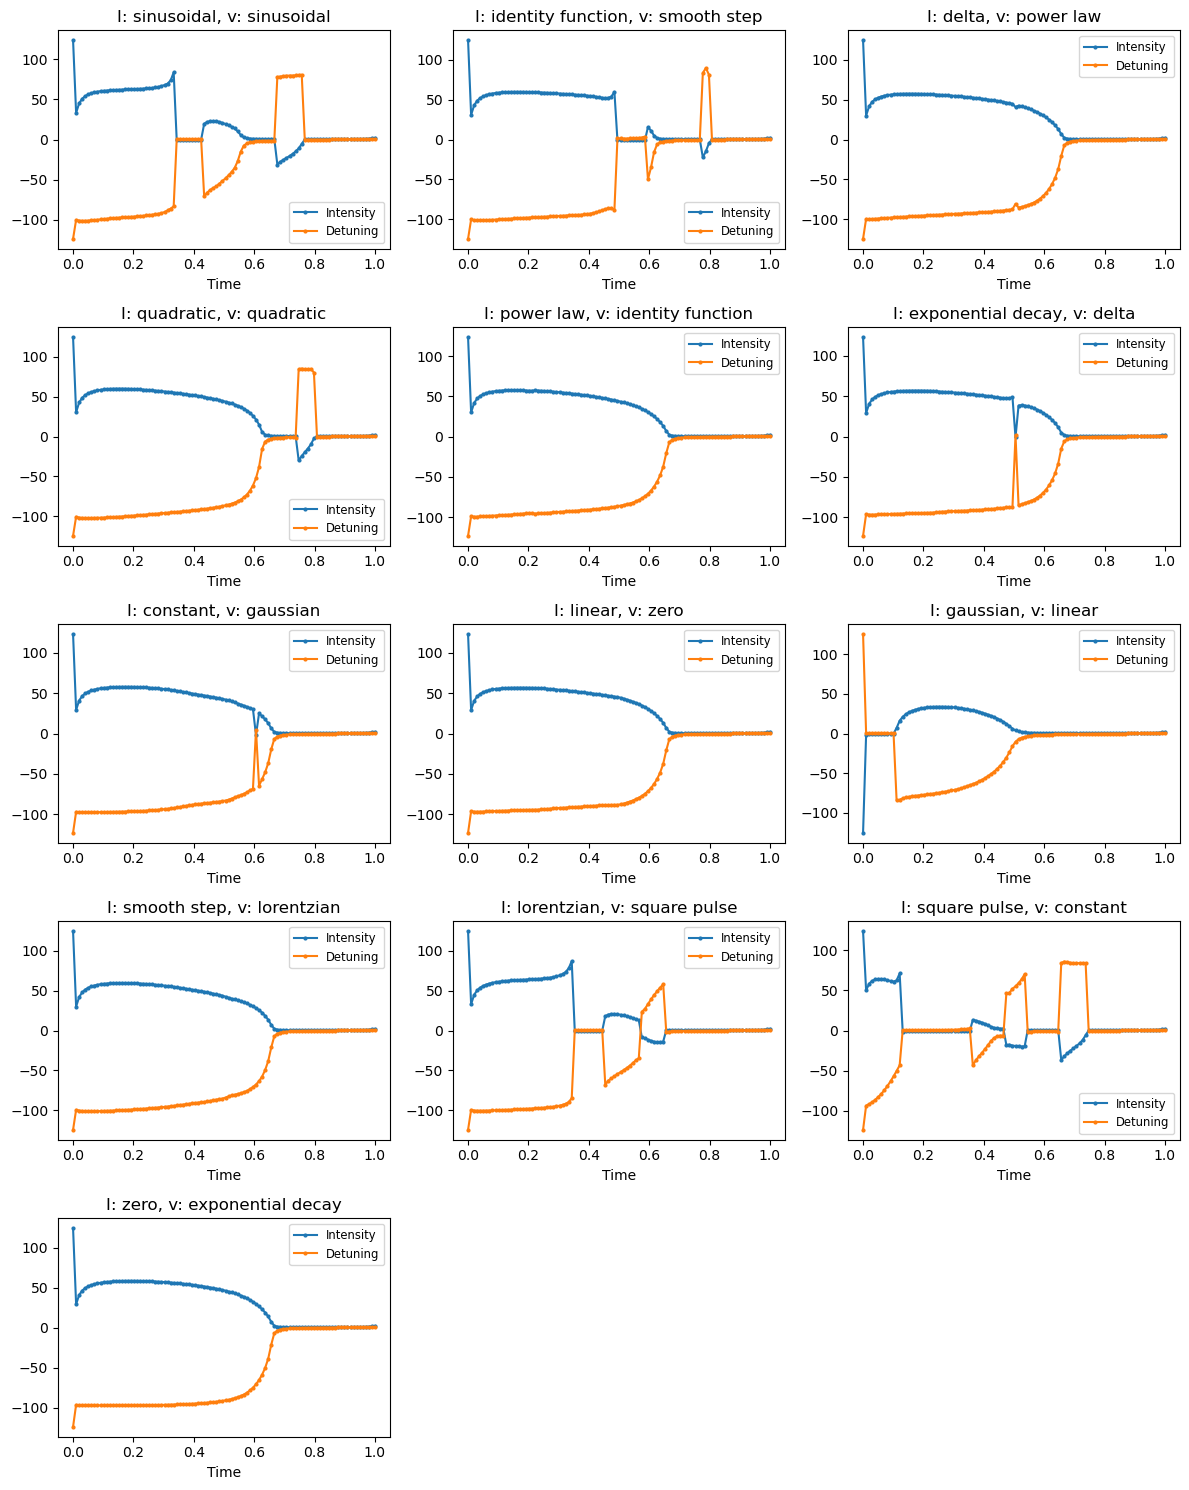

In [33]:
# Irr - Steps = 10,000
%run ./optimiser.ipynb

def loss_fn(params):
    return -irr_loss_eng(params["I"], params['v'])
    
def opt_irr_loss(params):
    return optimise(loss_fn, params, steps=10000)

%run ./test.ipynb
test_run = run_random_tests(
    opt_irr_loss,
    {
        "I": {'name': "Intensity"},
        "v": {'name': "Detuning", "positive": False},
    },
    array_length=100,
    plot_title="",
    plot_columns=3,
    make_plots=True,
)



Average function call time: 0.689265 s over 13 call(s).


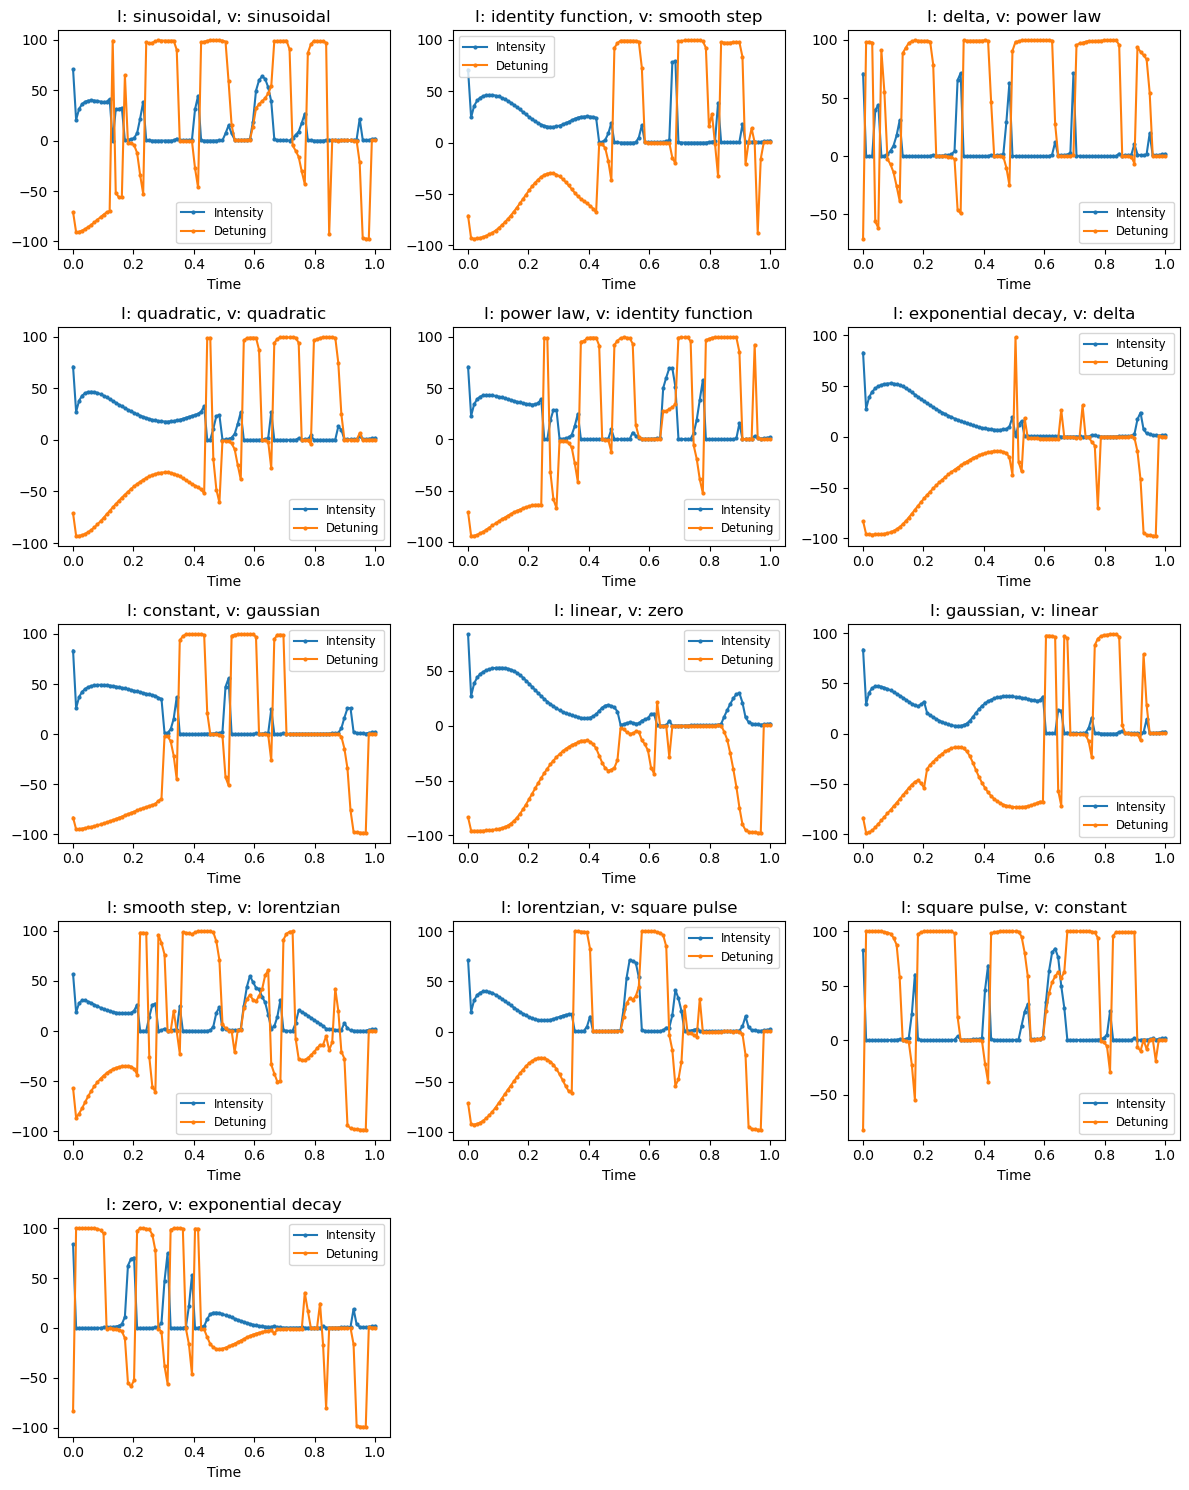

In [46]:
# Reg - Steps = 1,000
%run ./optimiser.ipynb

def loss_fn(params):
    return -reg_loss_eng(params["I"], params['v'])
    
def opt_reg_loss(params):
    params = optimise(loss_fn, params, steps=1000)
    params['I'] = bounded_I(params['I'])
    params['v'] = bounded_v(params['v'])
    return params

%run ./test.ipynb
test_run = run_random_tests(
    opt_reg_loss,
    {
        "I": {'name': "Intensity"},
        "v": {'name': "Detuning", "positive": False},
    },
    array_length=100,
    plot_title="",
    plot_columns=3,
    make_plots=True,
)


Average function call time: 3.498720 s over 13 call(s).


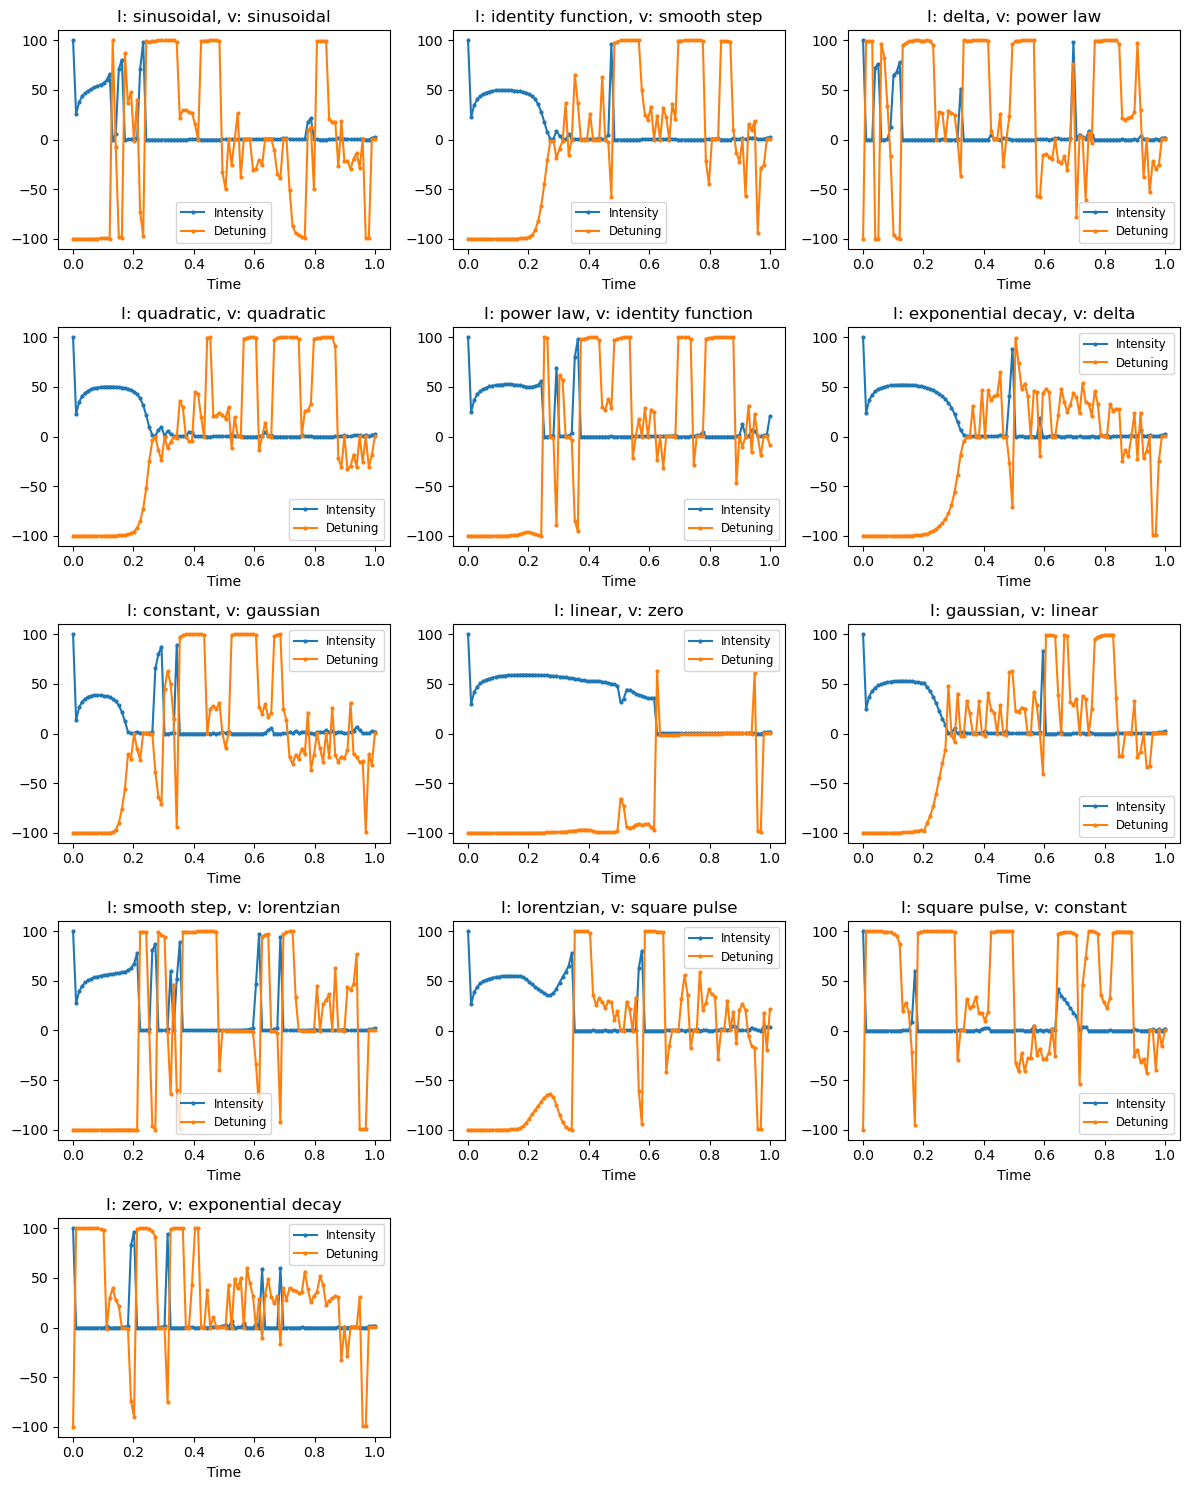

In [48]:
# Reg - Steps = 10,000
%run ./optimiser.ipynb

def loss_fn(params):
    return -reg_loss_eng(params["I"], params['v'])
    
def opt_reg_loss(params):
    params = optimise(loss_fn, params, steps=10000)
    params['I'] = bounded_I(params['I'])
    params['v'] = bounded_v(params['v'])
    return params
    
%run ./test.ipynb
test_run = run_random_tests(
    opt_reg_loss,
    {
        "I": {'name': "Intensity"},
        "v": {'name': "Detuning", "positive": False},
    },
    array_length=100,
    plot_title="",
    plot_columns=3,
    make_plots=True,
)
